# <b>Query Classifier

### Importing the Libraries

In [3]:
import torch
from torchmetrics import Accuracy
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from peft import LoraConfig, TaskType, get_peft_model
from datasets import load_dataset

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import math
import time

/Users/tanmaykhomane/Artificial Intelligence/GenAI IBM/llm_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Import the Dataset

In [12]:
dataset = load_dataset("csv", data_files = "../Datasets/kaarshika_bert_intent_2000.csv")
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

Train-Test Splitting

In [13]:
dataset['train'][0]

{'text': 'Should I apply an organic manure treatment to my brinjal?',
 'label': 'DECISION'}

In [14]:
dataset['train'] = dataset['train'].class_encode_column('label')
dataset['train']

Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})

In [15]:
dataset = dataset['train'].train_test_split(
    test_size = 0.05,
    seed = 42,
    stratify_by_column = 'label'
)

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 1900
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 100
    })
})

## Tokenization

In [16]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

In [17]:
def tokenize_function(examples):
    return tokenizer(examples['text'], padding = 'max_length', truncation = True)

In [18]:
tokenized_dataset = dataset.map(tokenize_function, batched = True)

Map: 100%|██████████| 100/100 [00:00<00:00, 17482.09 examples/s]


In [19]:
tokenized_dataset = tokenized_dataset.remove_columns(['text'])
tokenized_dataset = tokenized_dataset.rename_column('label', 'labels')
tokenized_dataset.set_format('torch')

## DataLoaders

In [20]:
train_dataloader = DataLoader(tokenized_dataset['train'], shuffle = True, batch_size = 8)
eval_dataloader = DataLoader(tokenized_dataset['test'], batch_size = 8)

In [22]:
num_labels = len(tokenized_dataset['train'].features['labels'].names)
num_labels

2

## Model

In [23]:
model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels = num_labels)

peft_config = LoraConfig (
    task_type = TaskType.SEQ_CLS,
    r = 16,
    lora_alpha = 32,
    target_modules = ['q_lin', 'v_lin'],
    lora_dropout = 0.1,
    bias = 'none'
)

model = get_peft_model(model, peft_config)

device = 'mps'
model.to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): DistilBertForSequenceClassification(
      (distilbert): DistilBertModel(
        (embeddings): Embeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (transformer): Transformer(
          (layer): ModuleList(
            (0-5): 6 x TransformerBlock(
              (attention): MultiHeadSelfAttention(
                (dropout): Dropout(p=0.1, inplace=False)
                (q_lin): Linear(
                  in_features=768, out_features=768, bias=True
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=1

In [24]:
model.print_trainable_parameters()

trainable params: 887,042 || all params: 67,842,052 || trainable%: 1.307510568813573


### Optimizer & Scheduler

In [25]:
optimizer = AdamW(model.parameters(), lr = 1e-3)
num_epochs = 3
num_training_steps = num_epochs * len(train_dataloader)

lr_scheduler = LambdaLR (
    optimizer,
    lr_lambda = lambda current_step : (1 - current_step / num_training_steps)
)

### Training Function

In [26]:
def train_model(model, tr_dataloader):
    progress_bar = tqdm(range(num_training_steps))

    model.train()
    tr_losses = []

    for epoch in range(num_epochs):
        total_loss = 0
        for batch in tr_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()

            total_loss += loss.item()
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()
            progress_bar.update(1)

        tr_losses.append(total_loss / len(tr_dataloader))

    plt.plot(tr_losses)
    plt.title("Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

### Evaluation Function

In [27]:
def evaluate_model(model, eval_dataloader):
    metric = Accuracy(task = "multiclass", num_classes = num_labels).to(device)

    model.eval()

    with torch.no_grad():
        for batch in eval_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim = -1)
            metric(predictions, batch['labels'])

    accuracy = metric.compute()

    print(f"Accuracy: {accuracy.item() * 100}")

### Training and Saving model

100%|██████████| 714/714 [09:25<00:00,  1.34it/s]

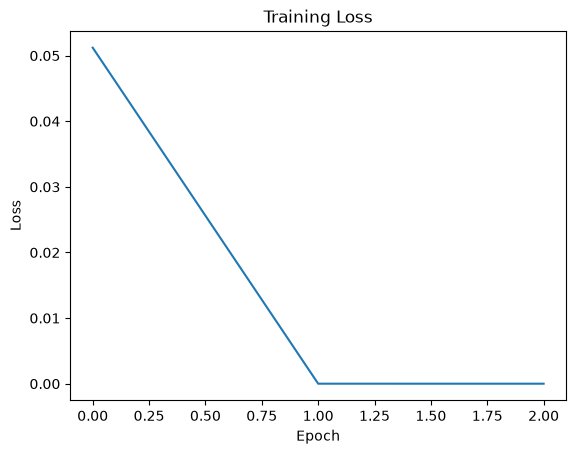

100%|██████████| 714/714 [09:25<00:00,  1.26it/s]


In [28]:
train_model(model = model, tr_dataloader = train_dataloader)
model.save_pretrained('classifier_lora')

In [29]:
evaluate_model(model, eval_dataloader)

Accuracy: 100.0


---

### Inference

In [30]:
device = "mps"

In [34]:
from peft import PeftModel

base_model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels = num_labels)

model = PeftModel.from_pretrained(base_model, 'classifier_lora')

model.to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


PeftModelForSequenceClassification(
  (base_model): LoraModel(
    (model): DistilBertForSequenceClassification(
      (distilbert): DistilBertModel(
        (embeddings): Embeddings(
          (word_embeddings): Embedding(30522, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (transformer): Transformer(
          (layer): ModuleList(
            (0-5): 6 x TransformerBlock(
              (attention): MultiHeadSelfAttention(
                (dropout): Dropout(p=0.1, inplace=False)
                (q_lin): Linear(
                  in_features=768, out_features=768, bias=True
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.1, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=1

### Test Run

In [39]:
label_names = tokenized_dataset['train'].features['labels'].names

text = "What is a fertilizer?"

inputs = tokenizer(text, return_tensors = 'pt', truncation = True, padding = True)
inputs = {k: v.to(device) for k, v in inputs.items()}

model.eval()

with torch.no_grad():
    outputs = model(**inputs)
    predicted_id = torch.argmax(outputs.logits, dim = 1).item()

print(f"Predicted Label: ", label_names[predicted_id])

Predicted Label:  INFORMATION
